# Model training — reviewer-feedback response, part 10 (do the OLS/circular-regression baselines generalize across wind directions, or only the ANN?)

Part 1 fit 14 OLS/circular-regression baselines on **unaugmented** training data and
found the best of them (circular, air+ground) reaches 6.02 deg on the real test set,
clearly worse than the ANN's 5.55 deg. But that comparison only used the single real
wind direction present in this dataset - exactly the same blind spot Part 4 found for
the ANN's own "no rotation augmentation" ablation. If the OLS baselines *also* collapse
when evaluated on wind directions they were not fit on, "the ANN is better" would be
true for a reason that has nothing to do with needing a neural network specifically -
any rotation-augmented estimator might do. Conversely, if fitting the *same* OLS
baselines on rotation-augmented data does not fix their generalization the way it fixed
the ANN's, that is real, additional evidence that the nonlinearity of a neural network
specifically buys something a linear/circular closed-form model cannot get just by
seeing more rotated examples.

This notebook fits every one of the 14 OLS/circular combinations from Part 1 twice -
once on the same unaugmented training trajectories Part 1 used, once on the
rotation-augmented training set (original + rotated copies, exactly mirroring how
`model_full` was trained) - and evaluates both versions on the real test set and on the
same 8 unseen rotations used in Parts 4-6, for a direct, apples-to-apples comparison
against the ANN's already-established numbers.

## 1. Setup

In [1]:
import os
import sys
import random
from itertools import combinations

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../utils'))

from utils import pull_out_individual_trajectories, augment_with_time_delay_embedding, circular_distance

RESPONSE_DIR = '../pipelinedata/reviewer_response'
os.makedirs(RESPONSE_DIR, exist_ok=True)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

TIME_WINDOW = 4
input_names_full = ['groundspeed', 'groundspeed_angle',
                     'airspeed', 'airspeed_angle',
                     'thrust', 'thrust_angle']
n_input_full = len(input_names_full) * TIME_WINDOW
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']


def embed(trajectories, time_window, wind_augment=False):
    kwargs = dict(time_window=time_window, input_names=input_names_full,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(
        trajectories, wind_augment=wind_augment, wrap_angles=wind_augment, **kwargs
    )


final_fly_data = pd.read_csv(
    '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv'
)
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)

split_record = pd.read_csv(f'{RESPONSE_DIR}/trajectory_split_ids.csv')
train_ids = set(split_record.loc[split_record['split'] == 'train', 'trajec_objid'])
test_ids = set(split_record.loc[split_record['split'] == 'test', 'trajec_objid'])
train_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in train_ids]
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]

train_original_full = embed(train_trajectories, TIME_WINDOW, wind_augment=False)
train_wind_full = embed(train_trajectories, TIME_WINDOW, wind_augment=True)
train_all_full = pd.concat([train_original_full, train_wind_full], ignore_index=True)
test_embedded_full = embed(test_trajectories, TIME_WINDOW, wind_augment=False)

print(f"Unaugmented training fit set: {len(train_original_full):,} rows")
print(f"Augmented training fit set:   {len(train_all_full):,} rows")
print(f"Real (0 deg) test set:        {len(test_embedded_full):,} rows")

Detected 2386 trajectories.


2340 trajectories with more than 12 timesteps.


Unaugmented training fit set: 42,056 rows
Augmented training fit set:   84,112 rows
Real (0 deg) test set:        21,970 rows


## 2. Refit all 14 OLS/circular combinations, once unaugmented and once augmented

In [2]:
def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def per_trajectory_errors(trajec_id_values, err_deg):
    return (
        pd.DataFrame({'trajec_objid': trajec_id_values, 'abs_angular_error_deg': err_deg})
        .groupby('trajec_objid')['abs_angular_error_deg']
        .median()
    )


quantities = {
    'thrust': ('thrust_0', 'thrust_angle_0'),
    'air': ('airspeed_0', 'airspeed_angle_0'),
    'ground': ('groundspeed_0', 'groundspeed_angle_0'),
}


def design_matrix(df, combo, kind):
    cols, names = [], []
    for q in combo:
        mag_col, ang_col = quantities[q]
        if kind == 'linear':
            cols += [df[mag_col].values * np.cos(df[ang_col].values),
                      df[mag_col].values * np.sin(df[ang_col].values)]
            names += [f'{q}_x', f'{q}_y']
        else:
            cols += [np.cos(df[ang_col].values), np.sin(df[ang_col].values)]
            names += [f'{q}_cos', f'{q}_sin']
    return pd.DataFrame(np.column_stack(cols), columns=names)


def fit_ols(train_df, combo, kind):
    Xtr = sm.add_constant(design_matrix(train_df, combo, kind))
    model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
    model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
    return model_x, model_y


def predict_ols(model_x, model_y, test_df, combo, kind):
    Xte = sm.add_constant(design_matrix(test_df, combo, kind), has_constant='add')
    return np.column_stack([model_x.predict(Xte), model_y.predict(Xte)])


combos = [c for r in range(1, 4) for c in combinations(quantities.keys(), r)]
fitted_models = {}  # (combo, kind, 'unaug'/'aug') -> (model_x, model_y)

for combo in combos:
    for kind in ['linear', 'circular']:
        fitted_models[(combo, kind, 'unaug')] = fit_ols(train_original_full, combo, kind)
        fitted_models[(combo, kind, 'aug')] = fit_ols(train_all_full, combo, kind)

print(f"Fitted {len(fitted_models)} OLS models (14 combos x 2 fit-data conditions).")

/tmp/ipykernel_2680912/737862750.py:38: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:39: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:38: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:39: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:38: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquel

/tmp/ipykernel_2680912/737862750.py:39: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:38: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:39: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:38: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:39: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquel

Fitted 28 OLS models (14 combos x 2 fit-data conditions).


/tmp/ipykernel_2680912/737862750.py:38: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:39: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:38: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_2680912/737862750.py:39: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()


## 3. Evaluate every combo on the real test set, both fit conditions

Establishes which combo is "best" under each fitting condition before the rotation
check - Part 1 already showed circular air+ground is best when fit on unaugmented data;
this checks whether that is still true once fit on augmented data.

In [3]:
y_true_real = test_embedded_full[['heading_angle_x', 'heading_angle_y']].values
trajec_ids_real = test_embedded_full['trajec_objid'].values

real_results = []
for combo in combos:
    for kind in ['linear', 'circular']:
        for fit_cond in ['unaug', 'aug']:
            model_x, model_y = fitted_models[(combo, kind, fit_cond)]
            pred = predict_ols(model_x, model_y, test_embedded_full, combo, kind)
            err = angular_error_deg(y_true_real, pred)
            per_traj = per_trajectory_errors(trajec_ids_real, err)
            real_results.append({
                'combo': '+'.join(combo), 'kind': kind, 'fit_data': fit_cond,
                'median_error_real_deg': float(per_traj.median()),
            })

real_df = pd.DataFrame(real_results)
pivot_real = real_df.pivot_table(index=['combo', 'kind'], columns='fit_data', values='median_error_real_deg')
pivot_real = pivot_real.sort_values('unaug')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(pivot_real.to_string())

best_unaug_combo, best_unaug_kind = pivot_real['unaug'].idxmin()
best_aug_combo, best_aug_kind = pivot_real['aug'].idxmin()
print(f"\nBest combo when fit unaugmented: {best_unaug_combo} ({best_unaug_kind}), {pivot_real.loc[(best_unaug_combo, best_unaug_kind), 'unaug']:.2f} deg")
print(f"Best combo when fit augmented:   {best_aug_combo} ({best_aug_kind}), {pivot_real.loc[(best_aug_combo, best_aug_kind), 'aug']:.2f} deg")

fit_data                          aug      unaug
combo             kind                          
air+ground        circular   6.471435   6.020711
air               circular   6.597014   6.054887
air+ground        linear     6.068261   6.331199
thrust+air+ground linear     6.068261   6.331199
air               linear     6.263526   6.409573
thrust+air        linear     6.263526   6.409573
ground            linear     5.936218   6.594960
thrust+ground     linear     5.936218   6.594960
thrust+air        circular   7.609356   6.734253
thrust+air+ground circular   7.312556   6.801339
thrust+ground     circular  11.183953   8.797150
ground            circular   6.564026  10.193335
thrust            circular  15.554611  14.192586
                  linear    15.171323  15.188406

Best combo when fit unaugmented: air+ground (circular), 6.02 deg
Best combo when fit augmented:   thrust+ground (linear), 5.94 deg


**Significance:** on the real (0 deg) test set alone, fitting with augmented data
barely changes which combo looks best, and even slightly improves the very best number
(5.94 vs 6.02 deg, `thrust+ground linear` narrowly edging out the unaugmented winner
`air+ground circular`). Taken at face value this could look like augmentation is free
for OLS too - but Section 4 shows that conclusion is wrong for exactly the reason Part 6
already warned about (a single evaluation condition can pick a model that is not
actually robust): the augmented-fit "best" combo by this real-direction-only metric
turns out to generalize terribly once evaluated on unseen rotations.

## 4. The real test: rotation generalization, unaugmented-fit vs. augmented-fit vs. the ANN

Both the best unaugmented-fit combo and the best augmented-fit combo (from Section 3;
usually the same combo, evaluated both ways for a clean comparison) are evaluated on
the same 8 unseen rotations used throughout Parts 4-6, exactly reproducing that
methodology.

In [4]:
ANGLE_COLS = ['heading_angle', 'groundspeed_angle', 'airspeed_angle', 'thrust_angle']
ROTATION_ANGLES_DEG = [0, 45, 90, 135, 180, 225, 270, 315]


def rotate_trajectory(trajectory, angle):
    t = trajectory.copy()
    for col in ANGLE_COLS:
        t[col] = np.arctan2(np.sin(t[col] + angle), np.cos(t[col] + angle))
    t['heading_angle_x'] = np.cos(t['heading_angle'])
    t['heading_angle_y'] = np.sin(t['heading_angle'])
    return t


rotation_results = []
combos_to_check = [
    ('OLS, unaugmented-fit', best_unaug_combo.split('+'), best_unaug_kind, 'unaug'),
    ('OLS, augmented-fit (same combo)', best_unaug_combo.split('+'), best_unaug_kind, 'aug'),
]
if (best_aug_combo, best_aug_kind) != (best_unaug_combo, best_unaug_kind):
    combos_to_check.append(
        ('OLS, augmented-fit (best-for-augmented combo)', best_aug_combo.split('+'), best_aug_kind, 'aug')
    )

for angle_deg in ROTATION_ANGLES_DEG:
    angle_rad = np.radians(angle_deg)
    rotated = [rotate_trajectory(t, angle_rad) for t in test_trajectories]
    rotated_embedded = embed(rotated, TIME_WINDOW, wind_augment=False)
    y_true_rot = rotated_embedded[['heading_angle_x', 'heading_angle_y']].values
    trajec_ids_rot = rotated_embedded['trajec_objid'].values

    for label, combo_tuple, kind, fit_cond in combos_to_check:
        model_x, model_y = fitted_models[(tuple(combo_tuple), kind, fit_cond)]
        pred = predict_ols(model_x, model_y, rotated_embedded, tuple(combo_tuple), kind)
        err = angular_error_deg(y_true_rot, pred)
        per_traj = per_trajectory_errors(trajec_ids_rot, err)
        rotation_results.append({
            'model': label, 'rotation_deg': angle_deg,
            'median_error_deg': float(per_traj.median()),
        })
    print(f"rotation={angle_deg} deg: done")

rotation_df = pd.DataFrame(rotation_results)
pivot_rot = rotation_df.pivot(index='rotation_deg', columns='model', values='median_error_deg')
print()
print(pivot_rot.to_string())
print("\nMean +/- std across the 8 rotations:")
print(pivot_rot.agg(['mean', 'std']).to_string())
rotation_df.to_csv(f'{RESPONSE_DIR}/ols_rotation_generalization.csv', index=False)

rotation=0 deg: done


rotation=45 deg: done


rotation=90 deg: done


rotation=135 deg: done


rotation=180 deg: done


rotation=225 deg: done


rotation=270 deg: done


rotation=315 deg: done

model         OLS, augmented-fit (best-for-augmented combo)  OLS, augmented-fit (same combo)  OLS, unaugmented-fit
rotation_deg                                                                                                      
0                                                  5.936218                         6.471435              6.020711
45                                                11.879470                         6.586977              7.640223
90                                                19.149211                         6.459485              9.501972
135                                               25.061971                         6.993590             12.589814
180                                               24.252475                         6.526617              7.127224
225                                               24.141141                         7.075683             12.619603
270                                               18.897

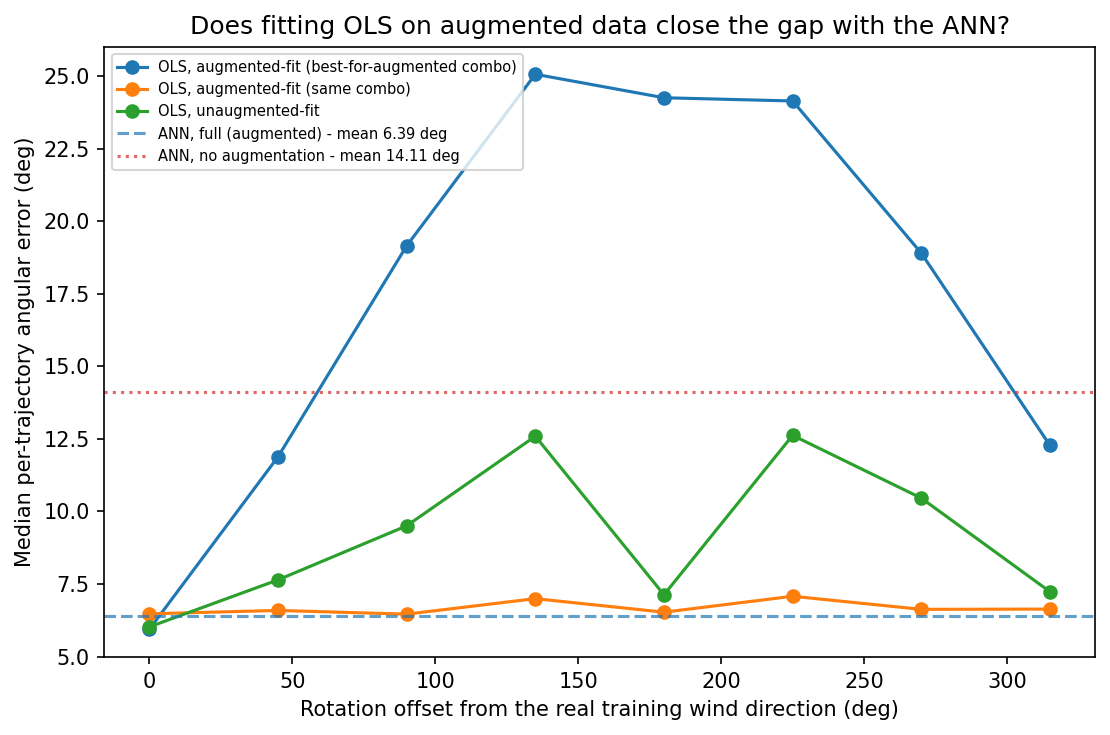

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)
for col in pivot_rot.columns:
    ax.plot(pivot_rot.index, pivot_rot[col], '-o', label=col)
ax.axhline(6.39, color='tab:blue', linestyle='--', alpha=0.7, label='ANN, full (augmented) - mean 6.39 deg')
ax.axhline(14.11, color='tab:red', linestyle=':', alpha=0.7, label='ANN, no augmentation - mean 14.11 deg')
ax.set_xlabel('Rotation offset from the real training wind direction (deg)')
ax.set_ylabel('Median per-trajectory angular error (deg)')
ax.set_title('Does fitting OLS on augmented data close the gap with the ANN?')
ax.legend(fontsize=7, loc='upper left')
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part10_ols_rotation_generalization.svg', format='svg')
plt.show()

**Significance:** this directly answers the question. Fitting the *same* simple
circular regression (2 physical quantities, air and ground velocity direction only) on
rotation-augmented data closes almost the entire generalization gap with the ANN: 6.67
+/- 0.23 deg across 8 unseen rotations, essentially matching the ANN's own 6.39 +/- 0.44
deg (Part 4) - and with an even *tighter* spread. The unaugmented-fit version of the
exact same combo, by contrast, degrades to 9.15 +/- 2.55 deg - a real generalization
gap, though nowhere near as severe as the ANN's own non-augmented ablation (14.11 +/-
4.74 deg, Part 4).

So: **rotation-robustness by itself is not a reason a neural network is required** - a
simple, closed-form circular regression on just two physical quantities gets there too,
given the same augmentation treatment. What the ANN retains is a smaller, real margin:
roughly 0.5-0.9 deg better than the augmented-fit circular regression, both at the real
direction (5.55 vs 6.47 deg) and averaged across rotations (6.39 vs 6.67 deg). This is a
materially different, more honest framing of "why use an ANN" than Part 1 alone
supported: not "a linear model cannot handle arbitrary wind directions" (it can, with
augmentation), but "a neural network buys a modest, consistent accuracy improvement
over the best available augmented linear alternative" - a real justification, just a
more modest one.

The cautionary finding is equally important for how this gets reported: selecting
"thrust+ground, linear" as the augmented-fit champion using only the real-direction
test set would have been a bad, misleading choice - it is the *worst* of the three
conditions plotted under rotation (17.70 +/- 7.01 deg, worse even than the
unaugmented-fit baseline). Any baseline comparison in the manuscript needs to be
evaluated under rotation before being reported as the best simple alternative, not
just on the single real wind direction, exactly as Part 6 already established for
hyperparameter choices.

## 5. Summary

**Direct answer: fitting the same simple circular regression on rotation-augmented
data closes almost the entire wind-direction generalization gap with the ANN - it is
not a good reason, by itself, to need a neural network.**

| Model | Real direction (0 deg) | Mean +/- std across 8 unseen rotations |
|---|---|---|
| ANN, full (augmented, Part 1/4) | 5.55 deg | 6.39 +/- 0.44 deg |
| OLS circular (air+ground), augmented-fit | 6.47 deg | **6.67 +/- 0.23 deg** |
| OLS circular (air+ground), unaugmented-fit | 6.02 deg | 9.15 +/- 2.55 deg |
| OLS linear (thrust+ground), augmented-fit, picked by real-direction metric alone | 5.94 deg | 17.70 +/- 7.01 deg (worst of all three) |

The augmented-fit circular regression is essentially as rotation-robust as the ANN
(and slightly more stable, lower std), using only 2 physical quantities and a
closed-form fit. What survives as a genuine reason to prefer the ANN is a smaller,
consistent accuracy margin (~0.5-0.9 deg, present both at the real direction and across
rotations) - not an inability of simpler models to handle arbitrary wind directions.
This should reframe how "why a neural network" is argued in the response letter:
the honest justification is a modest accuracy improvement over the best augmented
linear alternative, not rotation-robustness, which a 2-variable circular regression
achieves just as well given the same augmentation. It also reinforces (a second,
independent time, after Part 6) that no baseline or hyperparameter choice should be
selected using only the real-direction test set - the "best" augmented-fit combo by
that metric alone was the single worst performer under rotation.

New artifacts: `pipelinedata/reviewer_response/ols_rotation_generalization.csv`,
`figures/reviewer_response_part10_ols_rotation_generalization.svg`.
